In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Sobre o dataset - Retailrocket
É um dataset de ecommerce baseado em eventos com informações sobre os itens (propriedades e categorias) que foram acessados.

##### 3 arquivos de dados principais:
- events.csv:
    - timestamp: timestamp (unix timestamp em milisegundos) do snapshot do evento;
    - visitorid: id unico do visitante;
    - event: tipo do evento: view, addtocart, transaction;
    - itemid: id unico do item;
    - transactionid: id unico da transacao, caso tenha na sessão.

- item_properties.сsv:
    - timestamp: timestamp (unix timestamp em milisegundos) do snapshot do evento;
    - itemid: id unico do item;
    - property: propriedade do item;
    - value: propriedade valor do item.

- category_tree.сsv:
    - categoryid: identificador unico da categoria;
    - parentid: identificador unico do "pai" da categoria, se for vazio nao existe "pai".


## 1. conhecendo o dataset - events

In [30]:
df_events = pd.read_csv("../data/interim/events.csv")

df_events.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [31]:
df_events['timestamp'] = pd.to_datetime(df_events['timestamp'], unit='ms')

df_events['data'] = df_events['timestamp'].dt.date
df_events['hora'] = df_events['timestamp'].dt.hour
df_events['dia_semana'] = df_events['timestamp'].dt.day_name()

In [32]:
print(df_events.shape)

(2756101, 8)


In [33]:
print(df_events.isnull().sum())

timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
data                   0
hora                   0
dia_semana             0
dtype: int64


In [34]:
print(df_events.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 8 columns):
 #   Column         Dtype         
---  ------         -----         
 0   timestamp      datetime64[ns]
 1   visitorid      int64         
 2   event          object        
 3   itemid         int64         
 4   transactionid  float64       
 5   data           object        
 6   hora           int32         
 7   dia_semana     object        
dtypes: datetime64[ns](1), float64(1), int32(1), int64(2), object(3)
memory usage: 157.7+ MB
None


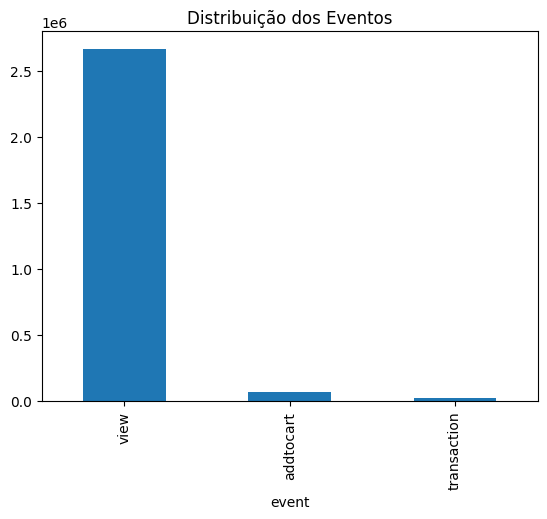

In [35]:
eventos = df_events['event'].value_counts()

eventos.plot(
    kind='bar'
)

plt.title('Distribuição dos Eventos')
plt.show()

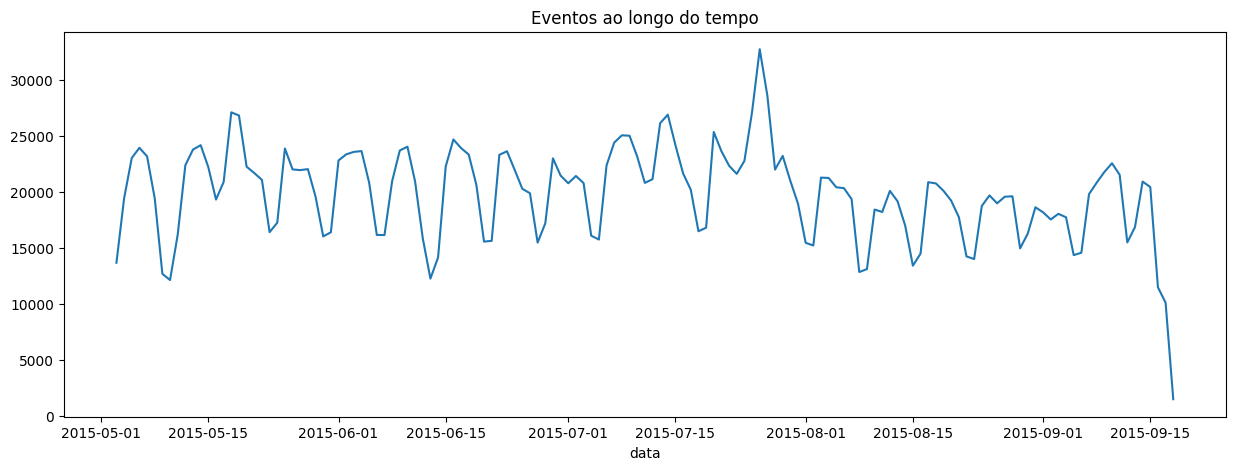

In [36]:
eventos_dia = (
    df_events.groupby('data')
      .size()
)

eventos_dia.plot(
    figsize=(15,5)
)

plt.title("Eventos ao longo do tempo")
plt.show()

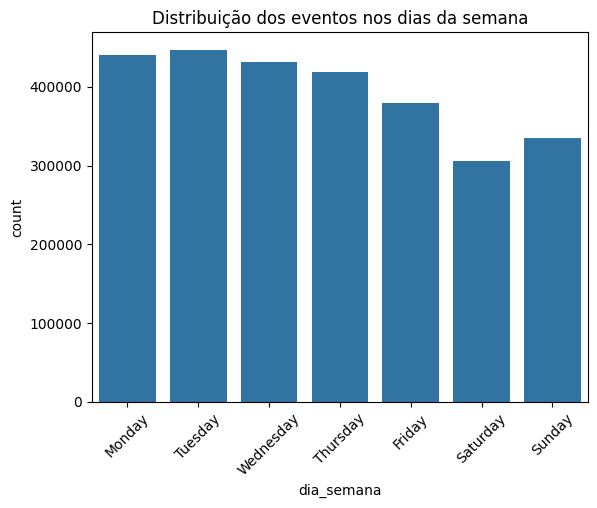

In [37]:
ordem = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

sns.countplot(
    data=df_events,
    x='dia_semana',
    order=ordem
)

plt.title("Distribuição dos eventos nos dias da semana")
plt.xticks(rotation=45)
plt.show()

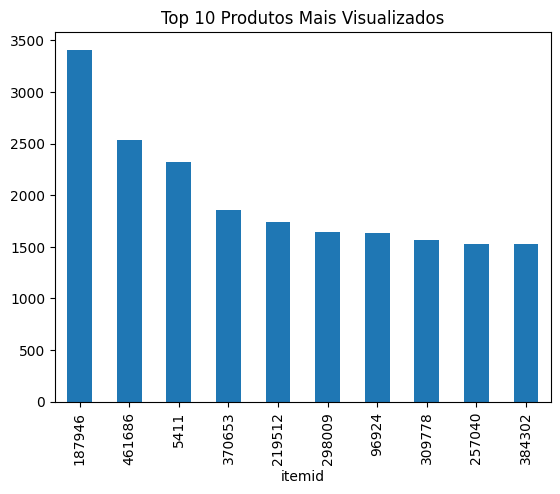

In [38]:
top_items = (
    df_events[df_events['event']=='view']
      ['itemid']
      .value_counts()
      .head(10)
)

top_items.plot(
    kind='bar'
)

plt.title('Top 10 Produtos Mais Visualizados')
plt.show()

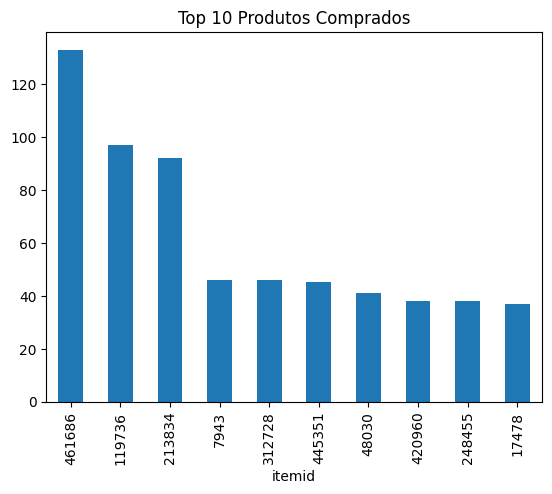

In [39]:
comprados = (
    df_events[df_events['event']=='transaction']
      ['itemid']
      .value_counts()
      .head(10)
)

comprados.plot(
    kind='bar'
)

plt.title('Top 10 Produtos Comprados')
plt.show()

In [40]:
interacoes_usuario = (
    df_events.groupby('visitorid')
      .size()
)

interacoes_usuario.describe()

count    1.407580e+06
mean     1.958042e+00
std      1.258049e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      7.757000e+03
dtype: float64

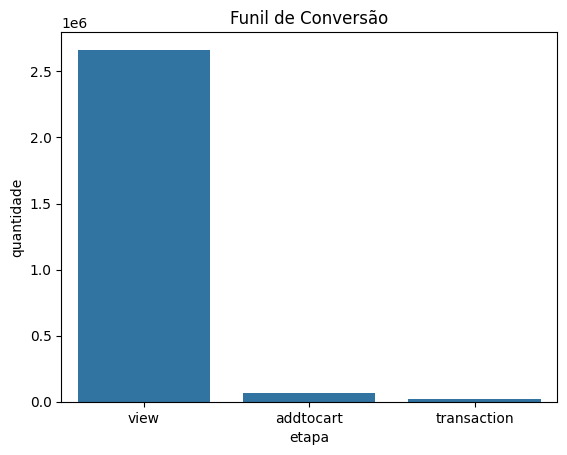

In [41]:
views = (df_events['event'] == 'view').sum()

cart = (df_events['event'] == 'addtocart').sum()

trans = (df_events['event'] == 'transaction').sum()


funil = pd.DataFrame({
    'etapa':['view','addtocart','transaction'],
    'quantidade':[views, cart, trans]
})

sns.barplot(
    data=funil,
    x='etapa',
    y='quantidade'
)

plt.title('Funil de Conversão')
plt.show()

In [42]:
df_events['peso'] = df_events['event'].map({
    'view':1,
    'addtocart':3,
    'transaction':5
})

interacoes = (
    df_events.groupby(
        ['visitorid','itemid']
    )['peso']
    .sum()
    .reset_index()
)

display(interacoes)

,visitorid,itemid,peso
0,0,67045,1
1,0,285930,1
2,0,357564,1
3,1,72028,1
4,2,216305,2
...,...,...,...
2145174,1407575,121220,1
2145175,1407576,356208,1
2145176,1407577,427784,1
2145177,1407578,188736,1


## 1. conhecendo o dataset - item propertie

In [44]:
df_prop_1 = pd.read_csv("../data/interim/item_properties_part1.csv")
df_prop_2 = pd.read_csv("../data/interim/item_properties_part2.csv")

df_prop = pd.concat([df_prop_1,df_prop_2], ignore_index=True)

df_prop.head()

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


In [45]:
df_prop['property'].value_counts().head(20)

property
888           3000398
790           1790516
available     1503639
categoryid     788214
6              631471
283            597419
776            574220
678            481966
364            476486
202            448938
839            417239
917            417227
764            417053
159            417053
112            417053
227            347492
698            289849
451            264416
663            240813
962            239372
Name: count, dtype: int64

In [46]:
props_por_item = (
    df_prop.groupby('itemid')
           .size()
)

<Axes: >

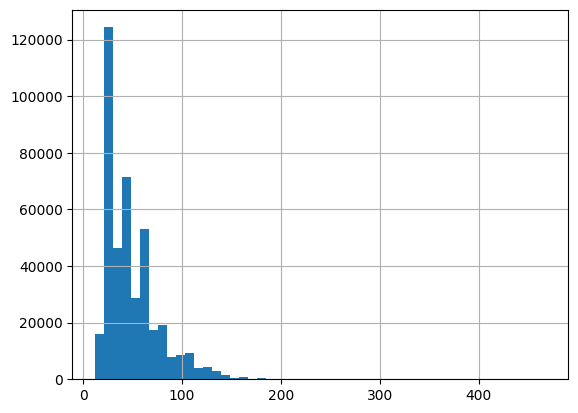

In [47]:
props_por_item.hist(bins=50)

In [1]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("RetailRocket")
    .getOrCreate()
)

In [ ]:
df_events = spark.read.csv(
    "../data/interim/events.csv",
    header=True,
    inferSchema=True
)

df_prop_1 = spark.read.csv(
    "../data/interim/item_properties_part1.csv",
    header=True,
    inferSchema=True
)

df_prop_2 = spark.read.csv(
    "../data/interim/item_properties_part2.csv",
    header=True,
    inferSchema=True
)


df_prop = df_prop_1.unionByName(df_prop_2)

df_prop.groupBy(
    "property"

).count().show()

+--------+------+
|property| count|
+--------+------+
|    1090| 22174|
|     675| 14152|
|     296|  4220|
|     829|  1356|
|     467|   325|
|     691|    83|
|     451|264416|
|     125|   491|
|     800|   162|
|     944|  1110|
|     853|  1153|
|     870|    47|
|     919|   130|
|     666|    14|
|     591| 50640|
|     447| 19823|
|      51|   501|
|     124|  9540|
|       7|   172|
|     307|  5016|
+--------+------+
only showing top 20 rows



In [5]:
# Pegar a última versão de cada propriedade
from pyspark.sql import Window
import pyspark.sql.functions as F

# É necessário definir a ordenação em uma janela para o last() funcionar de forma previsível
window_spec = Window.partitionBy("itemid", "property").orderBy("timestamp").rowsBetween(Window.unboundedPreceding, Window.unboundedFollowing)

df_prop_last = (
    df_prop
    # Aplica a função last sobre a janela para manter a ordem correta do timestamp
    .withColumn("last_value", F.last("value").over(window_spec)) # Substitua 'value' pelo nome da sua coluna de dados
    # Agrupa para remover as duplicadas e trazer o resultado final
    .groupBy("itemid", "property")
    .agg(F.last("value").alias("value"), F.last("timestamp").alias("timestamp"))
)


In [6]:
props = df_prop_last[
    df_prop_last['property']
    .isin([
        'categoryid',
        'available'
    ])
]

In [7]:
props.show(10)

+------+----------+-----+-------------+
|itemid|  property|value|    timestamp|
+------+----------+-----+-------------+
|     0| available|    0|1431831600000|
|     3| available|    0|1431226800000|
|     4|categoryid| 1038|1431831600000|
|     8| available|    0|1433646000000|
|    26| available|    0|1440298800000|
|    27|categoryid|  769|1431226800000|
|    34| available|    0|1431226800000|
|    44|categoryid|  227|1431226800000|
|    54|categoryid|  472|1431226800000|
|    69| available|    0|1431226800000|
+------+----------+-----+-------------+
only showing top 10 rows



In [9]:
df_items = (
    props
    # 1. O 'index' vira o groupBy
    .groupBy("itemid")
    # 2. O 'columns' vira o argumento do pivot
    .pivot("property")
    # 3. O 'values' entra dentro de uma função de agregação (ex: first ou max)
    .agg(F.first("value"))
)

In [11]:
df_eda = df_events.join(
    df_items,
    on='itemid',
    how='left'
)

In [12]:
df_eda.show()

+------+-------------+---------+---------+-------------+---------+----------+
|itemid|    timestamp|visitorid|    event|transactionid|available|categoryid|
+------+-------------+---------+---------+-------------+---------+----------+
|  2711|1436215190619|  1300250|     view|         NULL|        1|       411|
| 16813|1440092860342|   907914|     view|         NULL|        1|      1173|
| 58123|1435177081834|   262804|     view|         NULL|        1|       209|
| 67888|1438885367625|    44453|     view|         NULL|     NULL|      NULL|
|111045|1436963166716|    32833|     view|         NULL|        1|       256|
|159979|1436215100173|  1092949|     view|         NULL|        1|        84|
|185553|1440091204828|   579844|     view|         NULL|     NULL|      NULL|
|206277|1436962573878|   919101|     view|         NULL|        0|      1613|
|213705|1434057313397|  1264832|     view|         NULL|        0|      1120|
|225257|1440093524842|  1002400|     view|         NULL|        

In [15]:
import seaborn as sns

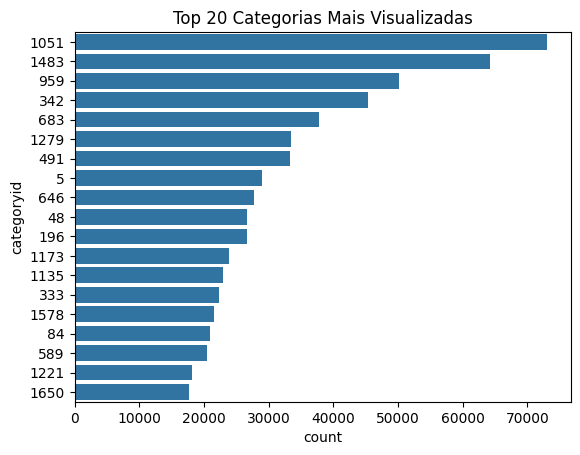

In [18]:
views_categoria = (
    df_eda
    .filter("event='view'")
    .groupBy("categoryid")
    .count()
    .orderBy("count", ascending=False)
    .limit(20)
    .toPandas()
)

sns.barplot(
    data=views_categoria,
    y="categoryid",
    x="count"
)

plt.title("Top 20 Categorias Mais Visualizadas")
plt.show()

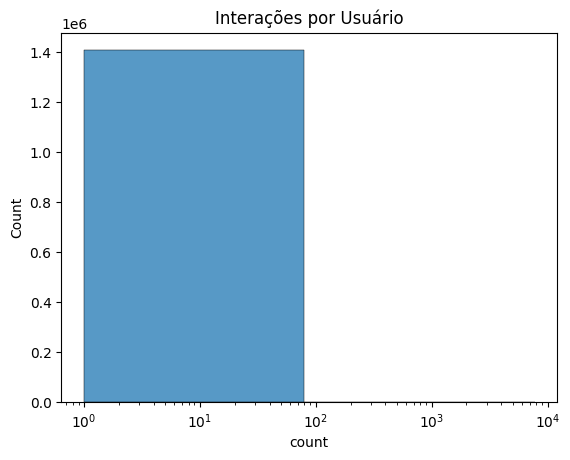

In [20]:
users = (
    df_eda
    .groupBy("visitorid")
    .count()
    .toPandas()
)

sns.histplot(
    users["count"],
    bins=100
)

plt.xscale("log")
plt.title("Interações por Usuário")
plt.show()


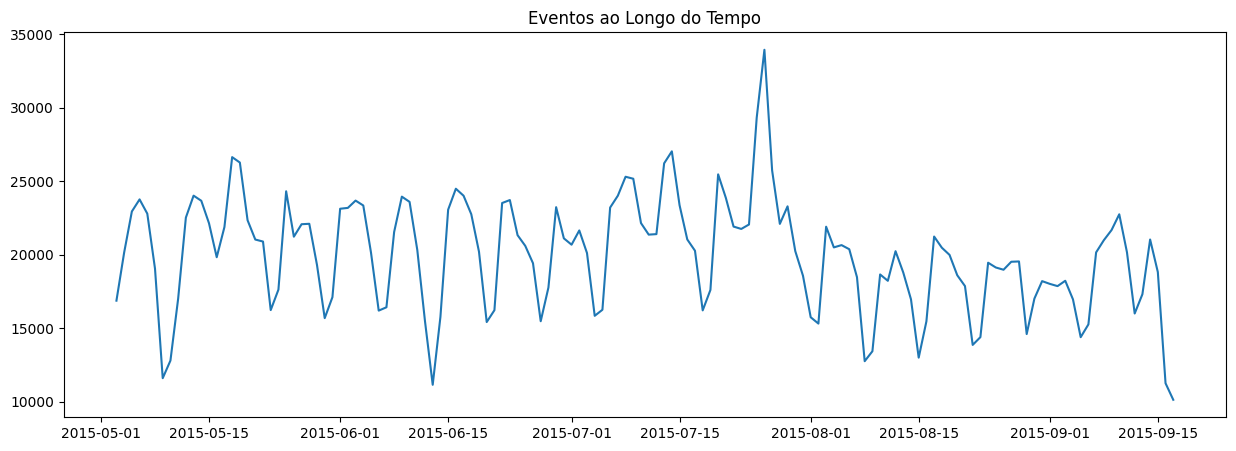

In [21]:
from pyspark.sql.functions import from_unixtime

df_temp = (
    df_eda.withColumn(
        "data",
        from_unixtime(
            F.col("timestamp")/1000
        ).cast("timestamp")
    )
)

timeline = (
    df_temp
    .groupBy(
        F.to_date("data")
    )
    .count()
    .orderBy("to_date(data)")
    .toPandas()
)

plt.figure(figsize=(15,5))

plt.plot(
    timeline.iloc[:,0],
    timeline["count"]
)

plt.title("Eventos ao Longo do Tempo")
plt.show()

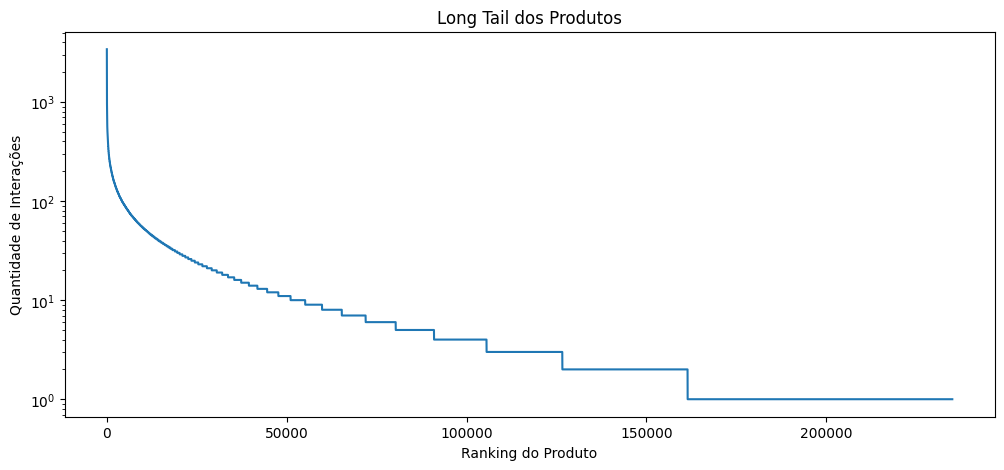

In [22]:
produto_pop = (
    df_eda
    .groupBy("itemid")
    .count()
    .orderBy("count", ascending=False)
    .toPandas()
)

plt.figure(figsize=(12,5))

plt.plot(
    range(len(produto_pop)),
    produto_pop["count"]
)

plt.yscale("log")

plt.title(
    "Long Tail dos Produtos"
)

plt.xlabel("Ranking do Produto")
plt.ylabel("Quantidade de Interações")
plt.show()

In [23]:
spark.stop

<bound method SparkSession.stop of <pyspark.sql.session.SparkSession object at 0x000001FAD83B2B50>>